In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Tracer.windfield import WindField
from Tracer.tracer import solver, initial_velocity, fetch_wind_data

## Investigating the difference between log and uniform wind

### Simulator

In [29]:
# play field parameters - dont touch unless necessary
P0 = [0,0,0]    # initial position
nx = 500        # length of play field
ny = 200        # width of play field
nz = 100        # height of play field
dt = 0.01       # time step

# Basis shot parameters - if not otherwise specified, these are used
shot_speed = 76.44384   # intital velocity
shot_angle = 10.4       # initial angle for trajectory	
shot_spin = 2545        # initial spin

# Basis wind parameters - if not otherwise specified, these are used
U_ref = 10      # reference wind speed at 10 meters above ground
z0 = 0.03       # surface roughness
direction = 0   # wind direction (0 is tailwind, 180 is headwind)

In [ ]:
# Simulation
def run_simulation(shot_speed=shot_speed, shot_angle=shot_angle, shot_spin=shot_spin, U_ref=U_ref, z0=z0, direction=direction):
    
    # trajectory with log wind
    log_wind = WindField(nx=nx, ny=ny, nz=nz, direction=direction, profile='log', z0=z0, U_ref=U_ref)
    log_V0 = initial_velocity(speed=shot_speed, angle=shot_angle)
    log_W0 = np.array([0, -shot_spin, 0])
    log_t, log_p, log_v, log_w = solver(P0, log_V0, log_W0, log_wind, dt=dt)

    # trajectory with uniform wind
    uni_wind = WindField(nx=nx, ny=ny, nz=nz, direction=direction, profile='uniform', z0=z0, U_ref=U_ref)
    uni_V0 = initial_velocity(speed=shot_speed, angle=shot_angle)
    uni_W0 = np.array([0, -shot_spin, 0])
    uni_t, uni_p, uni_v, uni_w = solver(P0, uni_V0, uni_W0, uni_wind, dt=dt)

    return log_p, uni_p

# Error     
def percent_distance_error(log_p,uni_p): 
    er = (np.sqrt((log_p[-1, 0] - uni_p[-1, 0])**2 + (log_p[-1, 1] - uni_p[-1, 1])**2) / np.sqrt((uni_p[-1, 0])**2 + (uni_p[-1, 1])**2))*100
    return er

# Varying one parameter function
def varying_parameter(param, param_name, param_unit, param_type,
                      shot_speed=shot_speed, shot_angle=shot_angle, 
                      shot_spin=shot_spin,U_ref=U_ref, z0=z0, direction=direction):

    param_results = []
    param_errors = []

    for value in param:

        # Setting parameters
        kwargs = {
            "shot_speed": shot_speed,
            "shot_angle": shot_angle,
            "shot_spin": shot_spin,
            "U_ref": U_ref,
            "z0": z0,
            "direction": direction
        }

        kwargs[param_type] = value

        # run_simulation using parameters 
        log_p, uni_p = run_simulation(**kwargs)

        param_results.append((log_p, uni_p))
        param_errors.append(percent_distance_error(log_p, uni_p))

    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Left plot: trajectories
    for i, (log_p, uni_p) in enumerate(param_results):
        ax1.plot(log_p[:, 0], log_p[:, 2], label=f'Log,{param[i]}{param_unit}')
        ax1.plot(uni_p[:, 0], uni_p[:, 2], '--', label=f'Uni,{param[i]}{param_unit}')

    ax1.set_xlabel("x")
    ax1.set_ylabel("z")
    ax1.set_title(f"Trajectories with varying {param_name}")
    ax1.legend()

    # Right plot: error vs parameter
    ax2.scatter(param, param_errors)
    ax2.plot(param, param_errors)

    for x, y in zip(param, param_errors):
        ax2.text(x, y, f"{y:.2f}", fontsize=8)
    
    ax2.set_xlabel(f"{param_name} ({param_unit})")
    ax2.set_ylabel("Landing position deviation (%)")
    ax2.set_title(f"Landing position deviation vs {param_name}")
    ax2.grid()

    plt.tight_layout()
    plt.show()

In [45]:
def varying_two_parameters(param1, param2,
                           param1_name, param2_name,
                           param1_unit, param2_unit,
                           param1_type, param2_type,
                           shot_speed=shot_speed, shot_angle=shot_angle, 
                           shot_spin=shot_spin, U_ref=U_ref, 
                           z0=z0, direction=direction):

    error_grid = []
    param_results = {}

    for i, val1 in enumerate(param1):

        row_errors = []

        for j, val2 in enumerate(param2):

            # Setting parameters (same structure as your 1D function)
            kwargs = {
                "shot_speed": shot_speed,
                "shot_angle": shot_angle,
                "shot_spin": shot_spin,
                "U_ref": U_ref,
                "z0": z0,
                "direction": direction
            }

            kwargs[param1_type] = val1
            kwargs[param2_type] = val2

            # Run simulation
            log_p, uni_p = run_simulation(**kwargs)

            # Store full result if you want later analysis
            param_results[(i, j)] = (log_p, uni_p)

            # Compute error
            row_errors.append(percent_distance_error(log_p, uni_p))

        error_grid.append(row_errors)

    error_grid = np.array(error_grid)

    # Error Heatmap
    fig, ax = plt.subplots(figsize=(7, 5))

    im = ax.imshow(error_grid, origin='lower', aspect='auto')

    cbar = plt.colorbar(im)
    cbar.set_label("Landing position deviation (%)")

    ax.set_xticks(range(len(param2)))
    ax.set_yticks(range(len(param1)))

    ax.set_xticklabels(param2)
    ax.set_yticklabels(param1)

    ax.set_xlabel(f"{param2_name} ({param2_unit})")
    ax.set_ylabel(f"{param1_name} ({param1_unit})")
    ax.set_title(f"Deviation vs {param1_name} and {param2_name}")

    # Optional: show values inside cells
    for i in range(len(param1)):
        for j in range(len(param2)):
            ax.text(j, i, f"{error_grid[i, j]:.2f}",
                    ha='center', va='center', fontsize=8)

    plt.tight_layout()
    plt.show()

    return error_grid, param_results

## Single variable variations

### Shot input variations: Shot speed, Shot angle, Shot spin

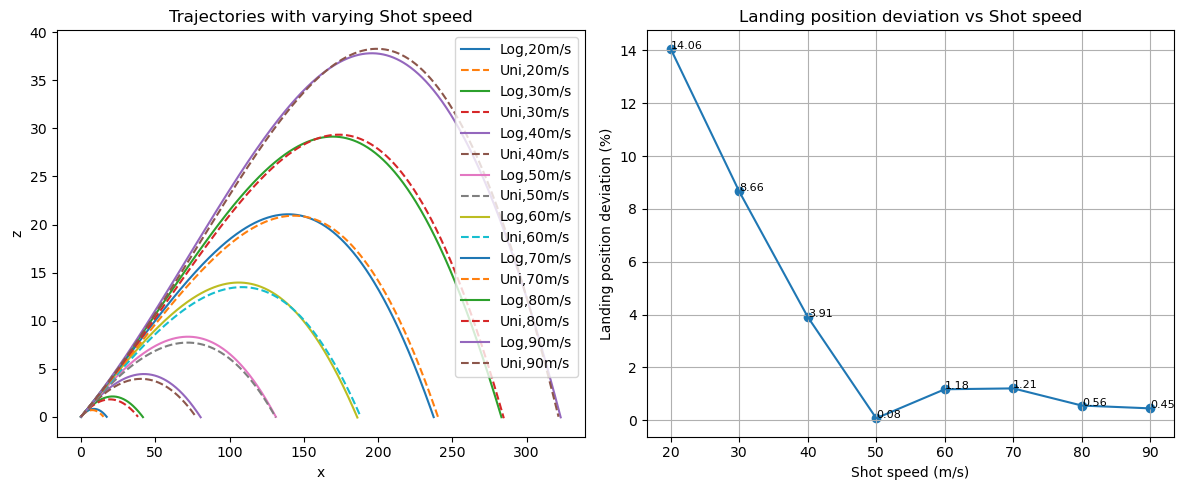

In [31]:
# Shot speed variation
param = [20, 30, 40, 50, 60, 70, 80, 90]
param_name = 'Shot speed'
param_unit = 'm/s'
param_type = "shot_speed"
varying_parameter(param, param_name, param_unit, param_type)

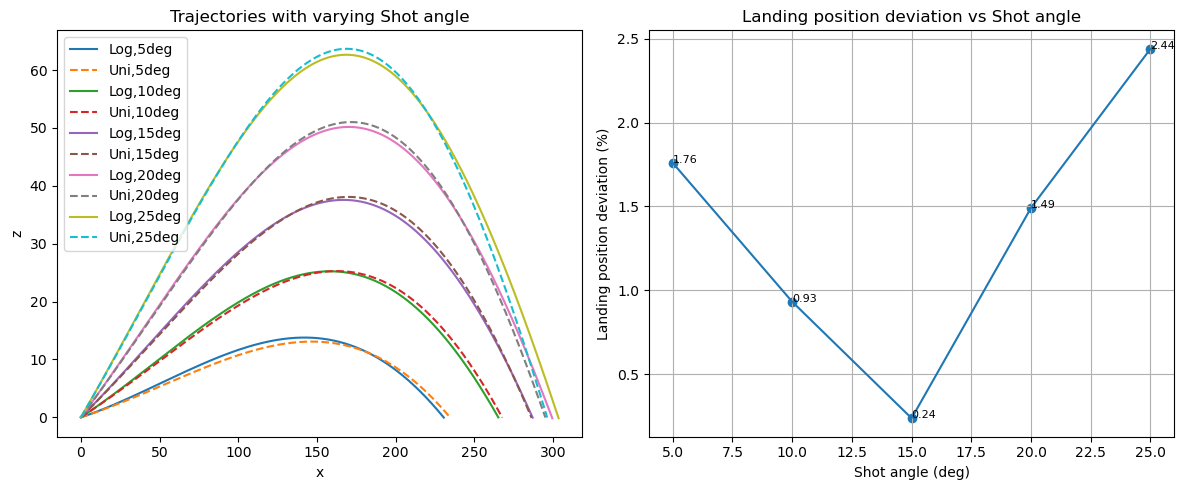

In [32]:
# Shot angle variation
param = [5, 10, 15, 20, 25]
param_name = 'Shot angle'
param_unit = 'deg'
param_type = "shot_angle"
varying_parameter(param, param_name, param_unit, param_type)

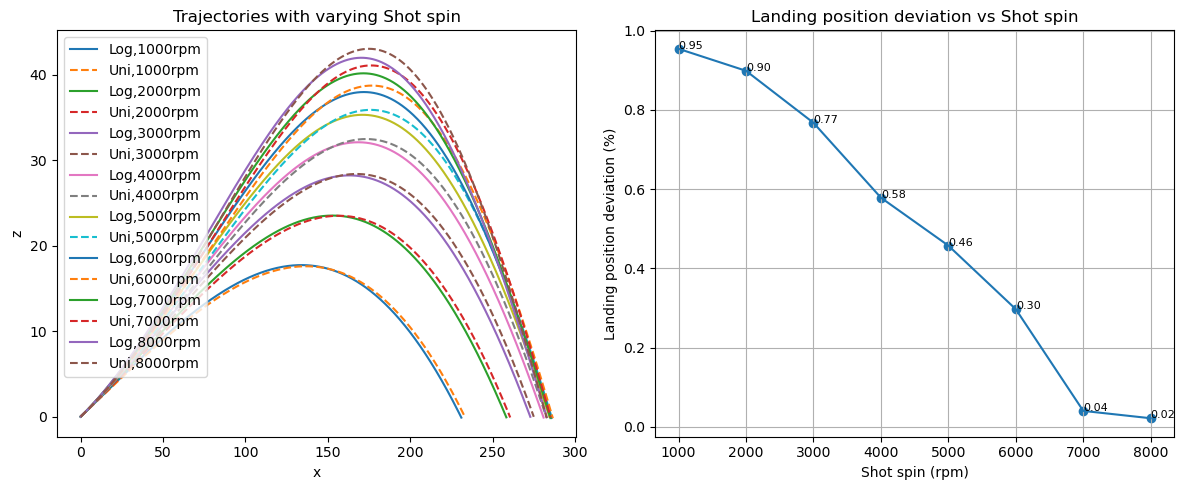

In [33]:
# Shot spin variation
param = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000]
param_name = 'Shot spin'
param_unit = 'rpm'
param_type = "shot_spin"

varying_parameter(param, param_name, param_unit, param_type)

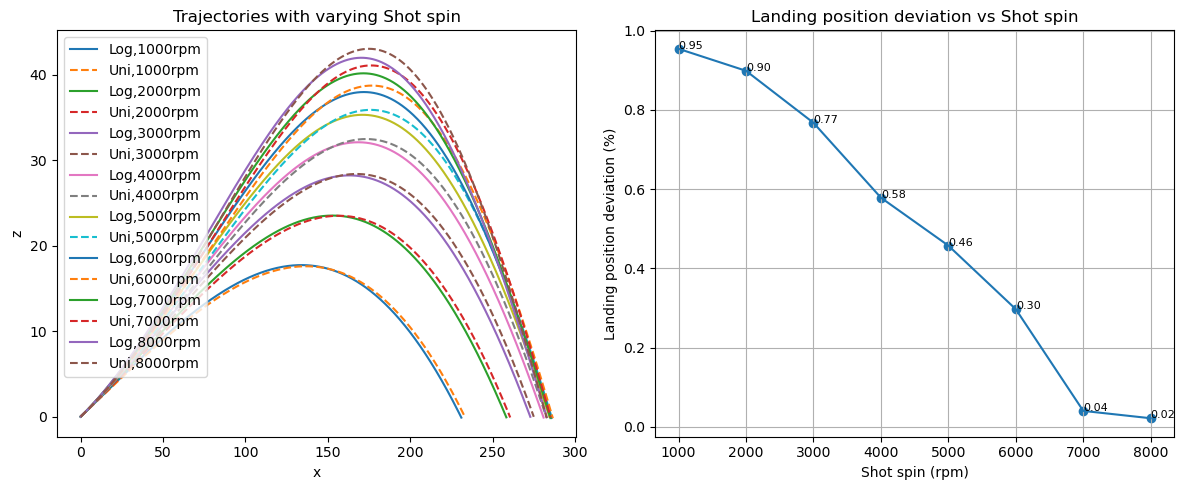

In [34]:
param = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000]
param_name = 'Shot spin'
param_unit = 'rpm'
param_type = "shot_spin"

varying_parameter(param, param_name, param_unit, param_type)

### Wind input variations: Wind speed, roughness, wind direction

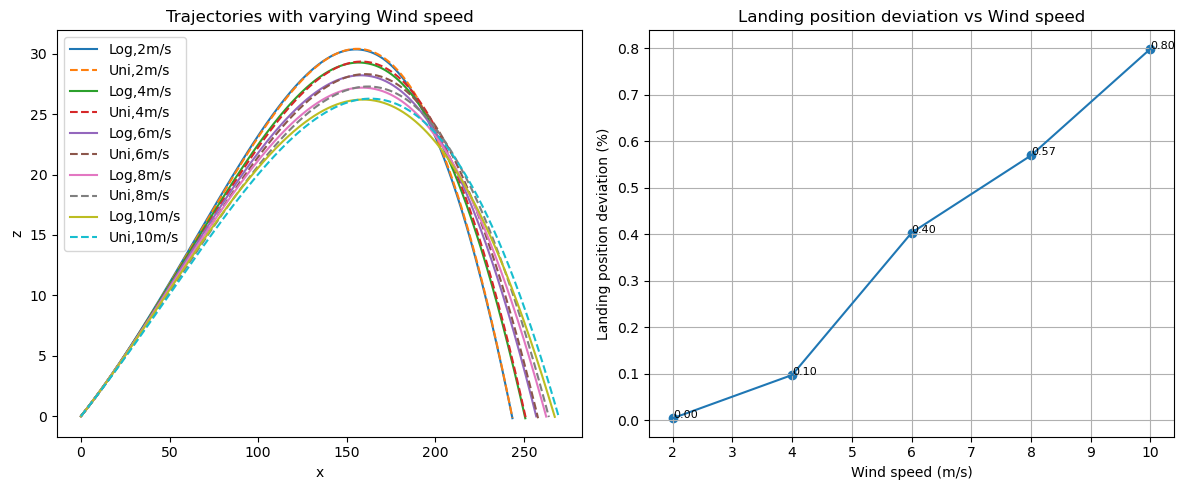

In [35]:
# Wind speed variation
param = [2, 4, 6, 8, 10]
param_name = 'Wind speed'
param_unit = 'm/s'
param_type = "U_ref"
varying_parameter(param, param_name, param_unit, param_type)

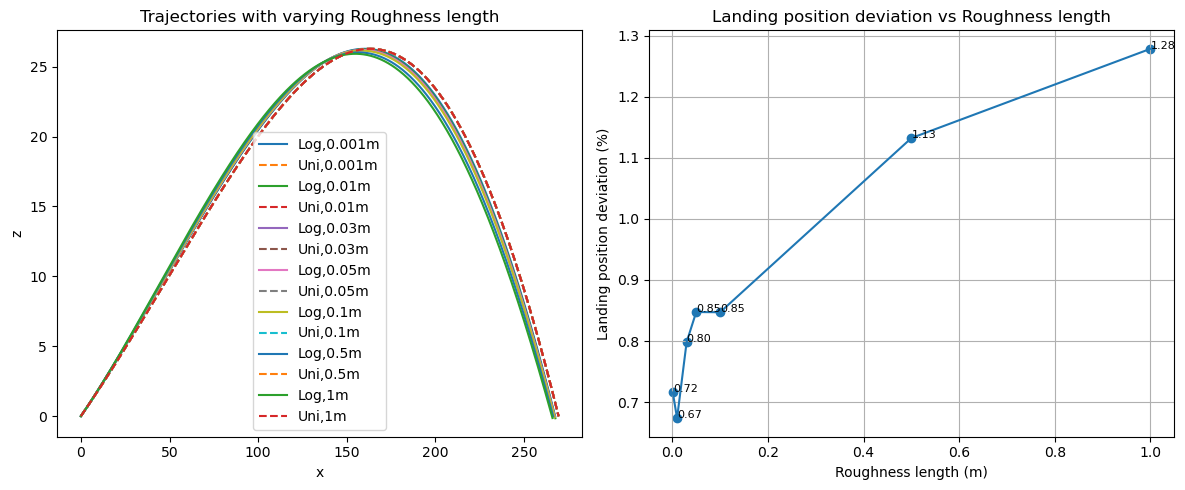

In [37]:
# Roughness variation
param = [0.001, 0.01, 0.03, 0.05, 0.1, 0.5, 1]
param_name = 'Roughness length'
param_unit = 'm'
param_type = "z0"
varying_parameter(param, param_name, param_unit, param_type)

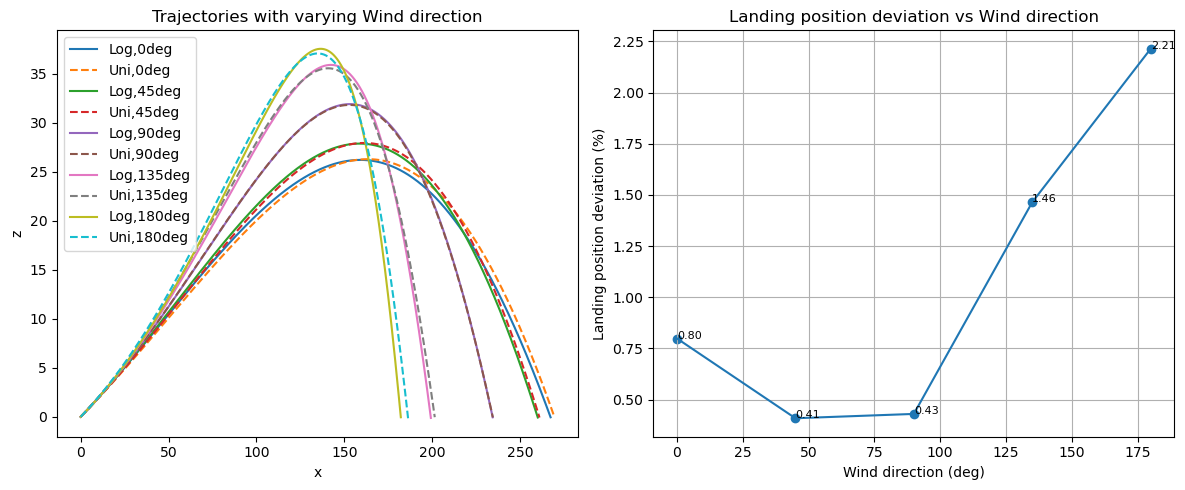

In [38]:
# Wind direction variation
param = [0, 45, 90, 135, 180]
param_name = 'Wind direction'
param_unit = 'deg'
param_type = "direction"
varying_parameter(param, param_name, param_unit, param_type)

## Changing multiple parameters

### Varying: Shot speed, Shot angle 

In [126]:
parameter_library = {
    "shot_speed": {
        "values": np.linspace(35, 85, 10, dtype=int),
        "name": "Shot speed",
        "unit": "m/s"
    },
    "shot_angle": {
        "values": np.linspace(5, 25, 10, dtype=int),
        "name": "Shot angle",
        "unit": "deg"
    },
    "shot_spin": {
        "values": np.linspace(2000, 10000, 10, dtype=int),
        "name": "Shot spin",
        "unit": "rpm"
    },
    "U_ref": {
        "values": np.linspace(2, 10, 10, dtype=int),
        "name": "Wind speed",
        "unit": "m/s"
    },
    "z0": {
        "values": np.logspace(np.log10(0.01), np.log10(1), 10),
        "name": "Roughness",
        "unit": "m"
    },
    "direction": {
        "values": np.linspace(0, 180, 10, dtype=int),
        "name": "Wind direction",
        "unit": "deg"
    }
}

# small fix to make z0 values nicer with less trailing digits
parameter_library['z0']['values'] = parameter_library['z0']['values'].round(2)

In [ ]:
def varying_two_parameters(param1_key, param2_key,
                           shot_speed=shot_speed, shot_angle=shot_angle, 
                           shot_spin=shot_spin, U_ref=U_ref, 
                           z0=z0, direction=direction):

    p1 = parameter_library[param1_key]
    p2 = parameter_library[param2_key]

    param1 = p1["values"]
    param2 = p2["values"]

    error_grid = []

    for val1 in param1:
        row_errors = []

        for val2 in param2:

            kwargs = {
                "shot_speed": shot_speed,
                "shot_angle": shot_angle,
                "shot_spin": shot_spin,
                "U_ref": U_ref,
                "z0": z0,
                "direction": direction
            }

            kwargs[param1_key] = val1
            kwargs[param2_key] = val2

            log_p, uni_p = run_simulation(**kwargs)
            row_errors.append(percent_distance_error(log_p, uni_p))

        error_grid.append(row_errors)

    error_grid = np.array(error_grid)

    # Plot
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(error_grid, origin='lower', aspect='auto',vmin=0,vmax=15)

    cbar = plt.colorbar(im)
    cbar.set_label("Landing position deviation (%)")

    ax.set_xticks(range(len(param2)))
    ax.set_yticks(range(len(param1)))

    ax.set_xticklabels(param2)
    ax.set_yticklabels(param1)

    ax.set_xlabel(f"{p2['name']} ({p2['unit']})")
    ax.set_ylabel(f"{p1['name']} ({p1['unit']})")
    ax.set_title(f"{p1['name']} vs {p2['name']}")

    plt.tight_layout()
    plt.show()

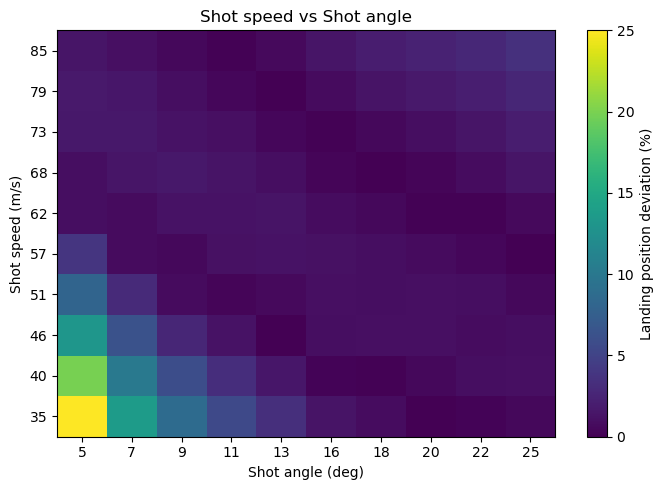

In [134]:
varying_two_parameters("shot_speed", "shot_angle")

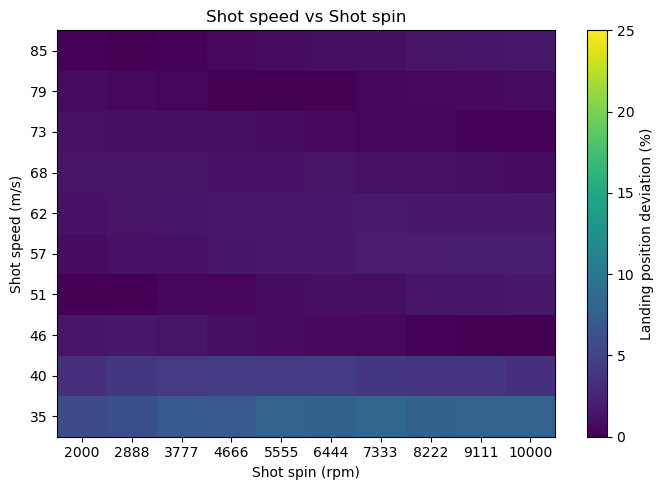

In [148]:
varying_two_parameters("shot_speed", "shot_spin")

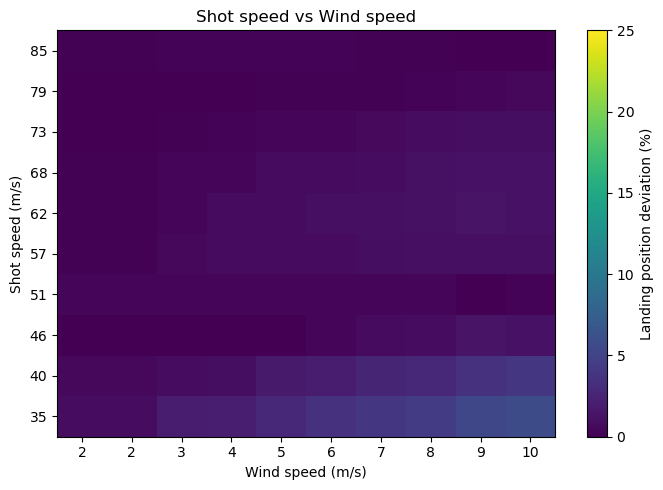

In [147]:
varying_two_parameters("shot_speed", "U_ref")

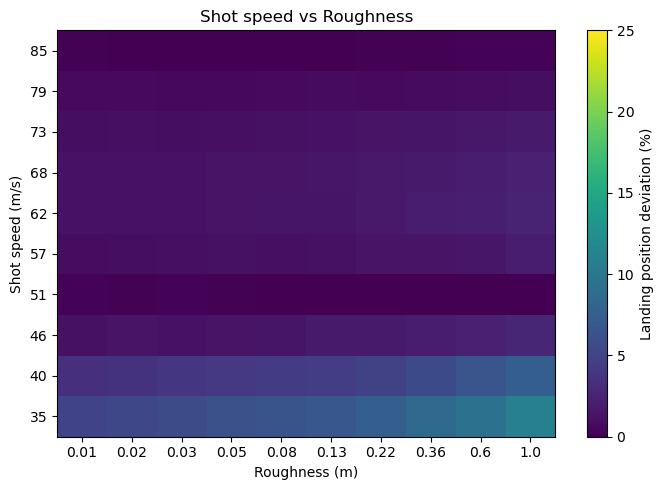

In [135]:
varying_two_parameters("shot_speed", "z0")

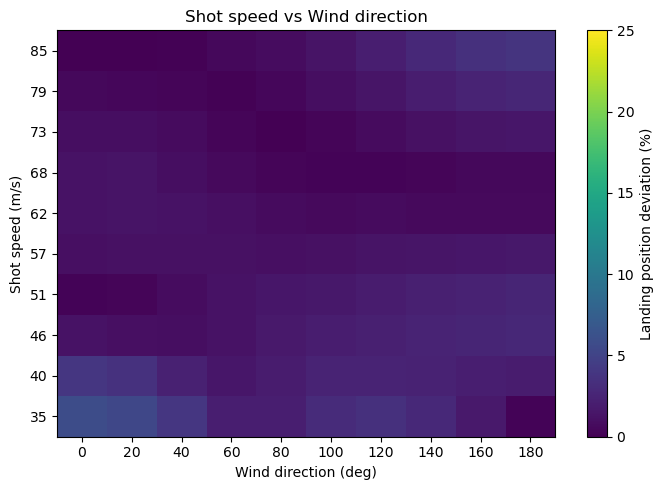

In [146]:
varying_two_parameters("shot_speed", "direction")

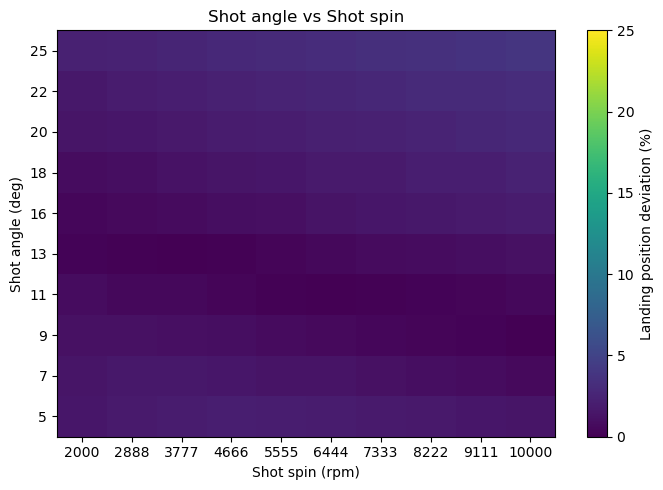

In [145]:
varying_two_parameters("shot_angle", "shot_spin")

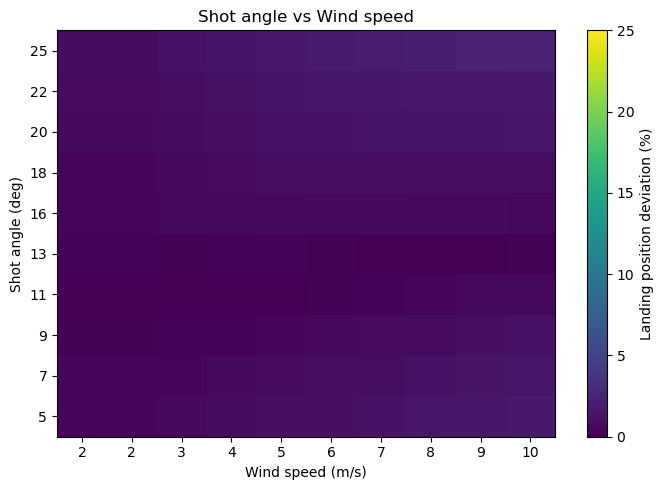

In [144]:
varying_two_parameters("shot_angle", "U_ref")

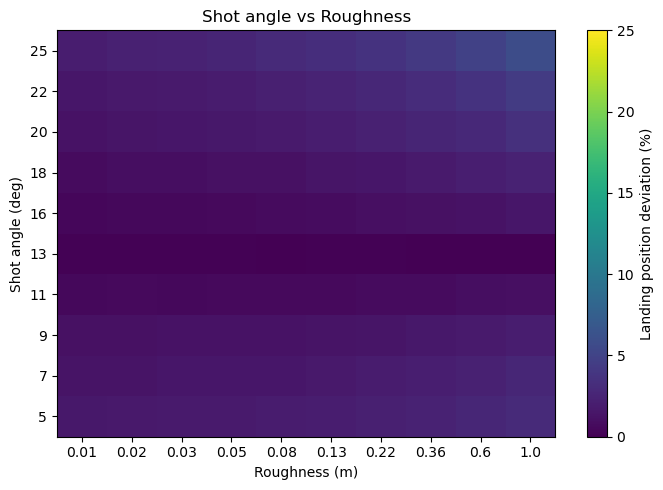

In [136]:
varying_two_parameters("shot_angle", "z0")

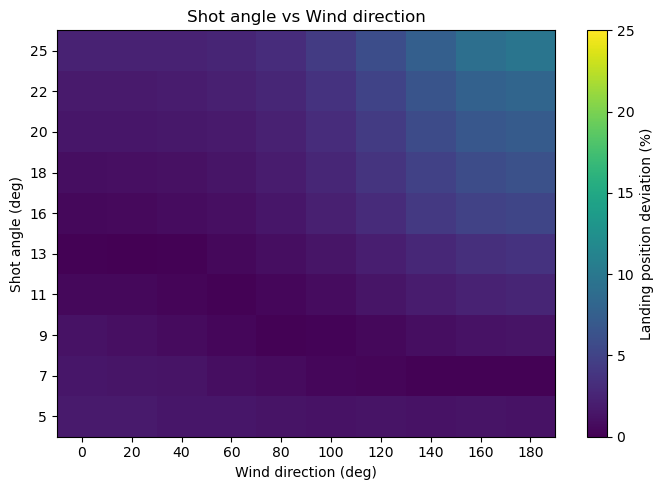

In [143]:
varying_two_parameters("shot_angle", "direction")

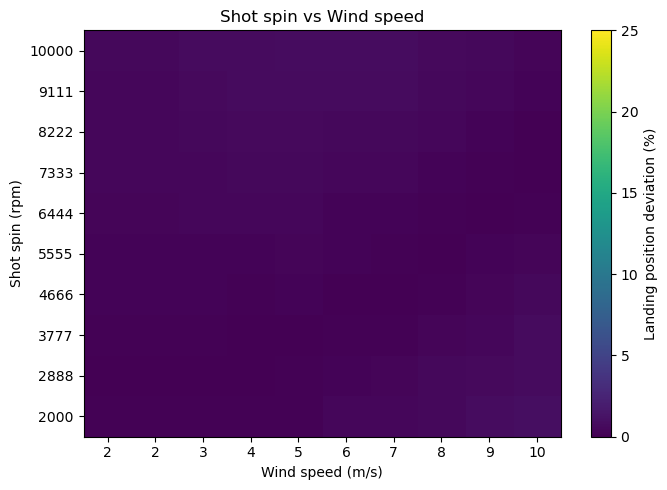

In [142]:
varying_two_parameters("shot_spin", "U_ref")

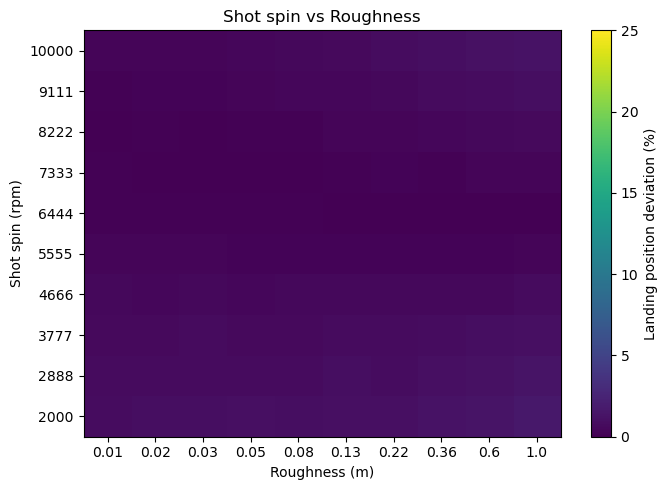

In [137]:
varying_two_parameters("shot_spin", "z0")

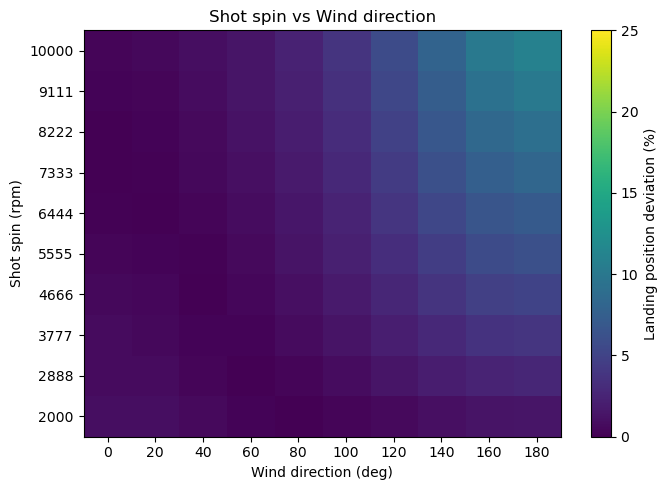

In [138]:
varying_two_parameters("shot_spin", "direction")

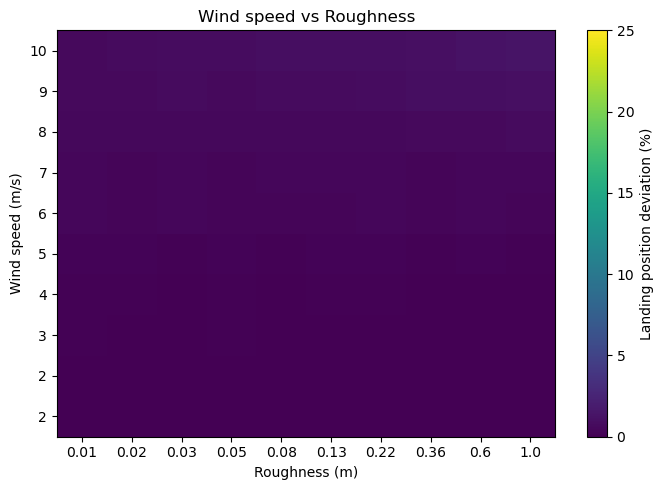

In [139]:
varying_two_parameters("U_ref", "z0")

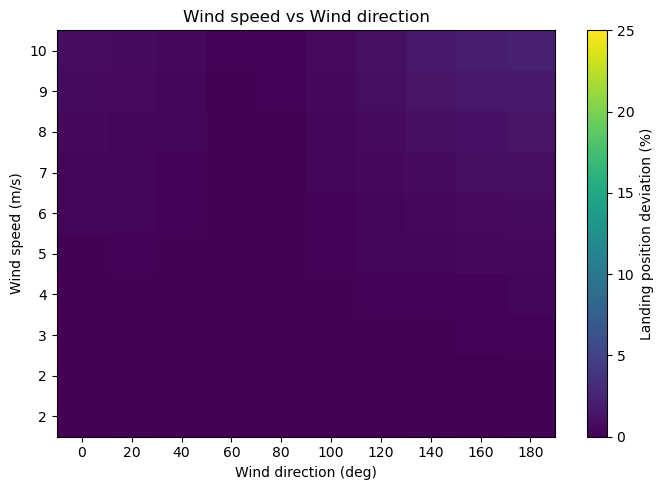

In [140]:
varying_two_parameters("U_ref", "direction")

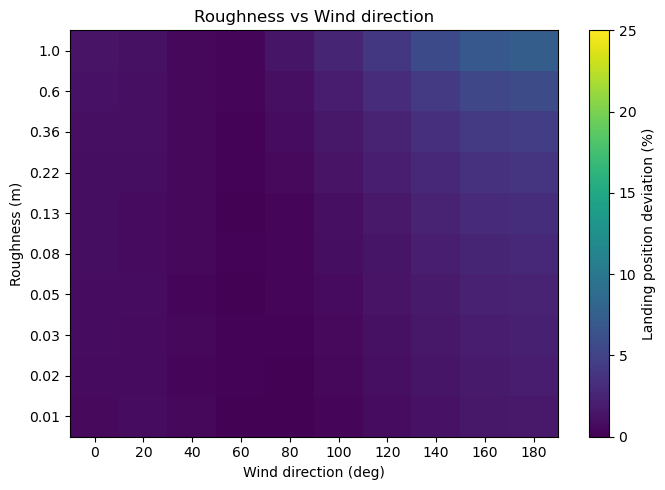

In [141]:
varying_two_parameters("z0", "direction")